# Analiza podatkov

Uvozimo prvo knjižnico Pandas in vzemimo podatke iz CSV datotek.

Uvozimo še knjižnico ipywidgets, ki jo bomo uporabili za interaktivne menije.

In [18]:
import pandas as pd
import ipywidgets as widgets


stat = pd.read_csv("CSV_datoteke/statistika.csv")
konf = pd.read_csv("CSV_datoteke/konference.csv")
raz = pd.read_csv("CSV_datoteke/razsirjeno.csv")

Združimo skupaj tabele, saj bomo za nekatere grafe potrebovali podatke iz večih tabel.

In [19]:
konf_2 = konf.drop(columns=["ime"])
raz_2 = raz.drop(columns=["ime"])
tabela = stat.merge(konf_2, on=["id", "leto"]).merge(raz_2, on=["id", "leto"])

### 1. del - Evolucija v času 1980 - 2026

Poglejmo si tabelo "statistika":

In [20]:
with pd.option_context("display.max_rows", 10):
    display(stat)

,id,ime,leto,odigrane minute,meti 3 točke,poskusi 3 točke,meti 2 točki,poskusi 2 točki,prosti meti,poskusi prostih metov,skoki v napadu,skoki v obrambi,asistence,ukradene žoge,blokade,izgubljene žoge,osebni prekrški
0,SAS,San Antonio Spurs,1980,19755,52,206,3804,7532,2024,2528,1153,2515,2326,771,333,1589,2103
1,LAL,Los Angeles Lakers,1980,19880,20,100,3878,7268,1622,2092,1085,2653,2413,774,546,1639,1784
2,CLE,Cleveland Cavaliers,1980,19930,36,187,3775,7854,1702,2205,1307,2381,2108,764,342,1370,1934
3,NYK,New York Knicks,1980,19780,42,191,3760,7481,1698,2274,1236,2303,2265,881,457,1613,2168
4,BOS,Boston Celtics,1980,19880,162,422,3455,6965,1907,2449,1227,2457,2198,809,308,1539,1974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1309,PHO,Phoenix Suns,2026,19755,1210,3348,2152,4041,1298,1663,1064,2471,2021,781,347,1188,1691
1310,IND,Indiana Pacers,2026,19755,1097,3084,2249,4220,1430,1842,806,2633,2269,605,374,1190,1710
1311,SAC,Sacramento Kings,2026,19755,843,2476,2565,4823,1443,1870,943,2523,2095,658,372,1175,1614
1312,MIL,Milwaukee Bucks,2026,19755,1240,3205,2105,3807,1142,1564,731,2610,2116,607,326,1247,1617


Hitro lahko opazimo, da se je čez leta število metov za tri točke močno povečalo. 

Poglejmo si, kako se povprečno število zadetih metov za tri točke spreminja čez leta in dodajmo zraven še povprečno število metov za dve točki in proste mete. Ker je število tekem v rednem delu v nekaterih letih manjše od standardnega, poglejmo število metov na tekmo.

Vzemimo skupno tabelo in ustvarimo nov stolpec z imenom "število iger".

In [21]:
tabela["število iger"] = tabela["zmage"] + tabela["porazi"]

Združimo podatke po letih in jih prikažimo z grafom.

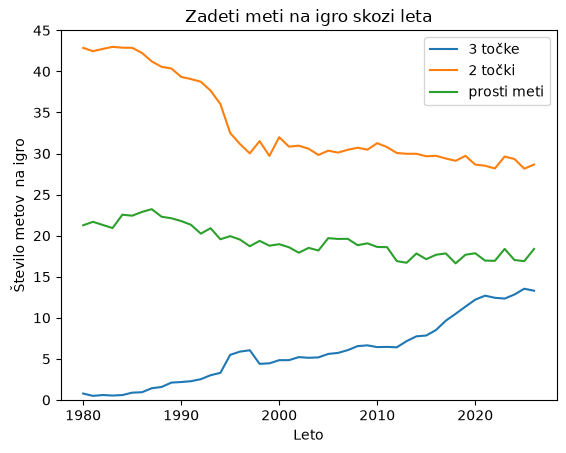

In [22]:
tocke = tabela.groupby("leto")[["meti 3 točke", "meti 2 točki", "prosti meti", "število iger"]].mean()

tocke["3 točke na tekmo"] = (tocke["meti 3 točke"] / tocke["število iger"])
tocke["2 točki na tekmo"] = (tocke["meti 2 točki"] / tocke["število iger"])
tocke["prosti meti na tekmo"] = (tocke["prosti meti"] / tocke["število iger"])

graf1 = tocke.plot(
    y=["3 točke na tekmo", "2 točki na tekmo", "prosti meti na tekmo"],
    title="Zadeti meti na igro skozi leta",
    xlabel="Leto",
    ylabel="Število metov  na igro"
)

graf1.set_ylim(0, 45)
graf1.legend(["3 točke", "2 točki", "prosti meti"])
graf1;

Res, lahko vidimo, da se je število metov za tri točke povečalo, hkrati se pa je število metov za dve točki ustrezno zmanjšalo.  

To lahko pojasnimo s tem, da so šele v sezoni 1979/80 uvedli mete za tri točke. Na začetku so bili dolgi meti košarkašem tuji, ščasoma pa so se taktike spremenile in dale večji pomen daljšim metom.

Število prostih metov pa se ni kaj preveč spremenilo.

___


Poglejmo si zdaj še razmerje med uspešnimi meti in poskusi metov. Ustvarimo novo tabelo s poskusi metov in jo združimo s prejšnjo tabelo.

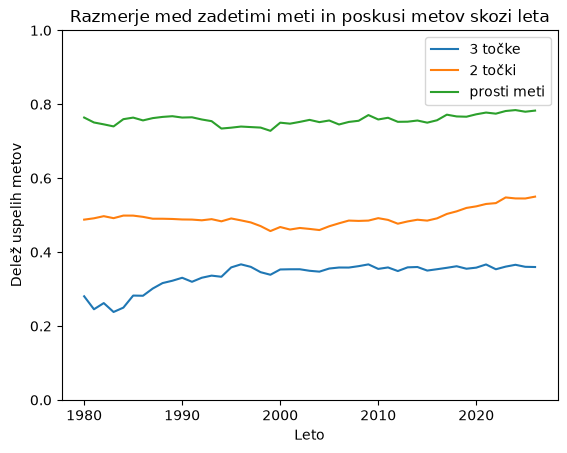

In [23]:
poskusi = tabela.groupby("leto")[["poskusi 3 točke", "poskusi 2 točki", "poskusi prostih metov"]].mean()

tocke_poskusi = tocke.merge(poskusi, on="leto")
tocke_poskusi["razmerje 3 točke"] = tocke_poskusi["meti 3 točke"] / tocke_poskusi["poskusi 3 točke"]
tocke_poskusi["razmerje 2 točki"] = tocke_poskusi["meti 2 točki"] / tocke_poskusi["poskusi 2 točki"]
tocke_poskusi["razmerje prosti meti"] = tocke_poskusi["prosti meti"] / tocke_poskusi["poskusi prostih metov"]

graf2 = tocke_poskusi.plot(
    y=["razmerje 3 točke", "razmerje 2 točki", "razmerje prosti meti"],
    title="Razmerje med zadetimi meti in poskusi metov skozi leta",
    xlabel="Leto",
    ylabel="Delež uspelih metov"
)

graf2.set_ylim(0, 1)
graf2.legend(["3 točke", "2 točki", "prosti meti"])
graf2;

Vidimo, da so košarkaši dosti bolj uspešni pri izvajanju prostih metov kot pa metov v igri. To je smiselno, saj so prosti meti izvedeni mirujoči in vedno iz istega mesta.

Tudi tukaj nam podatki kažejo, da košarkaši na začetku niso bili vajeni dolgih metov, saj se je delež uspešnih metov za tri točke stabiliziral šele okoli leta 2000.

Delež uspešnih prostih metov je bolj ali manj isti čez vsa leta, trend za uspešne mete za dve točki pa v zadnjem desetletju kaže rahlo navzgor.

___

V tabeli "konference" imamo za vsako ekipo podatek o povprečnih danih in prejetih točkah na tekmo. 

In [24]:
with pd.option_context("display.max_rows", 10):
    povp_tocke = konf.iloc[:, [0, 1, 2, 7, 8]]
    display(povp_tocke)


,id,ime,leto,povprečne dane točke,povprečne prejete točke
0,BOS,Boston Celtics,1980,113.5,105.7
1,PHI,Philadelphia 76ers,1980,109.1,104.9
2,WSB,Washington Bullets,1980,107.0,109.5
3,NYK,New York Knicks,1980,114.0,115.1
4,NJN,New Jersey Nets,1980,108.3,109.5
...,...,...,...,...,...
1309,SAS,San Antonio Spurs,2026,119.8,111.5
1310,HOU,Houston Rockets,2026,115.2,110.0
1311,NOP,New Orleans Pelicans,2026,115.5,120.0
1312,DAL,Dallas Mavericks,2026,114.1,119.6


Poglejmo si, kako sta se ta dva podatka spreminjala za posamezne ekipe skozi čas.

Ustvaril bom interaktivni meni, v katerem lahko izberete ekipo, in prikazal se vam bo ustrezen graf.

In [ ]:
meni = widgets.Dropdown(
    options = povp_tocke["ime"].unique(),
    description = "Ekipa:"
    )


def narisi(ekipa):
    podatki = povp_tocke[povp_tocke["ime"] == ekipa]

    podatki.plot(
        x="leto",
        y=["povprečne dane točke", "povprečne prejete točke"],
        title=f"Povprečne dane/prejete točke na tekmo za ekipo {ekipa}",
        marker="s",
        ylabel="točke"
    )

widgets.interact(narisi, ekipa=meni);

interactive(children=(Dropdown(description='Ekipa:', options=('Boston Celtics', 'Philadelphia 76ers', 'Washing…

Opomba: če gledate datoteko iz GitHub-a, se vam interaktivni meni ne bo prikazal. Datoteko morate odpreti v programu VSCode, da vam pravilno deluje.

Tisto leto, ko je povprečje danih točk vidno večje od povprečja prejetih točk, je bila ekipa med boljšimi.
  
Na veliko grafih je razvidno, da so približno med leti 1995 in 2015 ekipe dajale in prejemale manj točk kot v obdobjih prej in kasneje. Poglejmo, če ta trend drži v splošnem. Pogledati moramo samo povprečne dane točke, saj bi za prejete dobili isto.

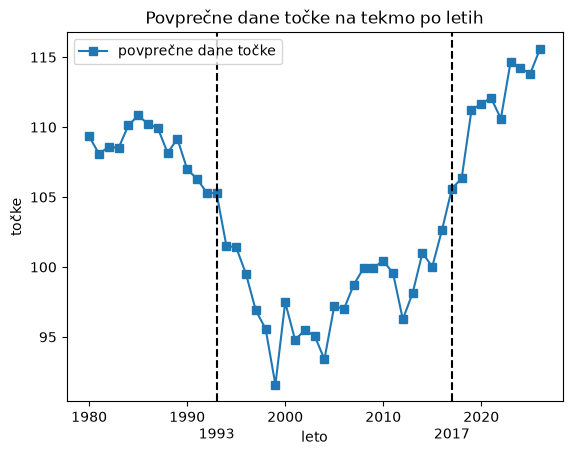

In [43]:
povp_skupno = povp_tocke.groupby("leto")[["povprečne dane točke"]].mean()

graf3 = povp_skupno.plot(
    y=["povprečne dane točke"],
    xlabel="leto",
    ylabel="točke",
    title="Povprečne dane točke na tekmo po letih",
    marker="s"
)

graf3.axvline(1993, linestyle="--", color="black")
graf3.axvline(2017, linestyle="--", color="black")

graf3.text(
    x=1993,
    y=-0.10,
    s="1993",
    transform=graf3.get_xaxis_transform(), # x axis pozicija je leto, y axis pozicija gre od 0 do 1
    ha="center"

)

graf3.text(
    x=2017,
    y=-0.10,
    s="2017",
    transform=graf3.get_xaxis_transform(),
    ha="center"

)

graf3;

Res, če narišemo navpični črti na letih 1993 in 2017, vidimo, da so ekipe v tem obdobju dajale manj točk. Razlog bi lahko bil v tem, da so se ekipe takrat osredotočale več na obrambo in dale poudarek daljši posesti žoge.

___

Poglejmo si zdaj podatke o tesnih tekmah (razlika točk manjša ali enaka 3) in tekmah z veliko razliko točk (razlika večja ali enaka 10). Zanima nas, ali se trend takih tekem z leti kaj spreminja. Spet moramo upoštevati različno število tekem na sezono, tako da bomo gledali razmerje teh tekem glede na vse tekme.
  
Vzemimo podatke iz tabele "razširjeno" in seštejmo tesne tekme in tekme z veliko razliko. Hkrati potrebujemo še število vseh tekem. To dobimo tako, da seštejemo vse tekme doma in v gosteh.

In [52]:
raz["tesna razlika"] = raz["zmage <= 3"] + raz["porazi <= 3"]
raz["velika razlika"] = raz["zmage >= 10"] + raz["porazi >= 10"]
raz["število tekem"] = raz["zmage doma"] + raz["porazi doma"] + raz["zmage v gosteh"] + raz["porazi v gosteh"]

Seštejmo tekme po letih. Rezultat moramo deliti z 2, ker smo tekme dvakrat šteli. Narišimo potem graf razmerja teh posebnih tekem v primerjavi z vsemi tekmami.

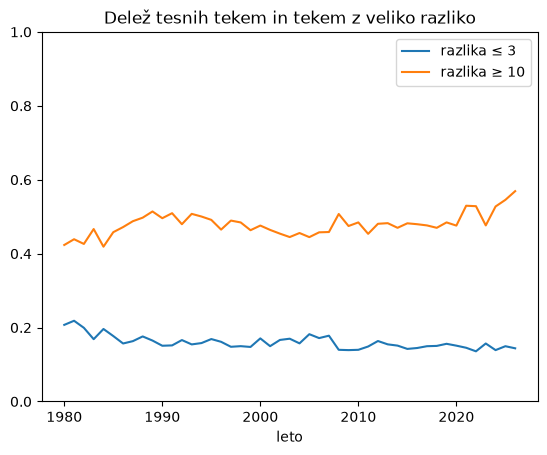

In [59]:
posebne_tekme = raz.groupby("leto")[["tesna razlika", "velika razlika", "število tekem"]].sum() / 2
posebne_tekme["delež tesnih"] = posebne_tekme["tesna razlika"] / posebne_tekme["število tekem"]
posebne_tekme["delež velika razlika"] = posebne_tekme["velika razlika"] / posebne_tekme["število tekem"]

graf4 = posebne_tekme.plot(
    y=["delež tesnih", "delež velika razlika"],
    title="Delež tesnih tekem in tekem z veliko razliko"
)

graf4.set_ylim(0, 1)
graf4.legend(["razlika ≤ 3", "razlika ≥ 10"])
graf4;

Trend se čez leta ni veliko spreminjal. Je pa zanimivo, da je približno dvakrat več tekem z veliko razliko kot pa tekem s tesno razliko.

___

Poglejmo si še obrambne karakteristike. To vključuje:
- skoke v napadu in obrambi (offensive, defensive rebounds)
- ukradene žoge (steals)
- blokade (blocks)
- izgubljene žoge (turnovers)
- osebne prekrške (personal fouls)

Spet bomo gledali povprečje na tekmo. Vzemimo skupno tabelo in narišimo graf vseh podatkov.

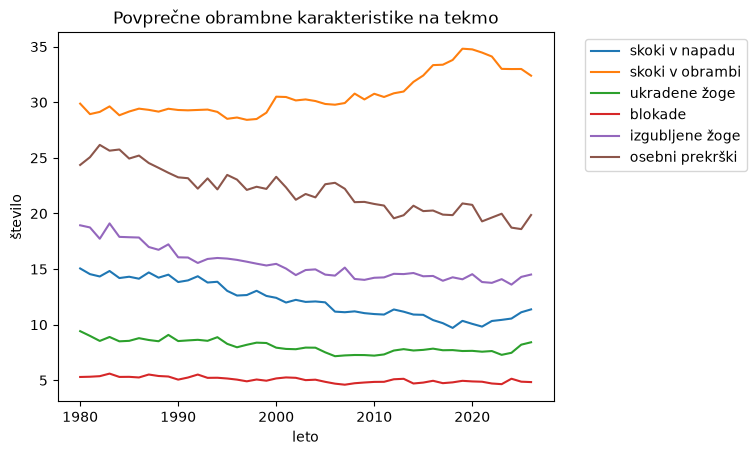

In [76]:
obramba = tabela.groupby("leto")[[
    "število iger",
    "skoki v napadu", 
    "skoki v obrambi", 
    "ukradene žoge", 
    "blokade", 
    "izgubljene žoge", 
    "osebni prekrški"
]].mean()

obramba_na_tekmo = obramba.div(obramba["število iger"], axis=0)

graf5 = obramba_na_tekmo.drop(columns="število iger").plot(
    ylabel="število",
    title="Povprečne obrambne karakteristike na tekmo"
)

graf5.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
graf5;

Vidimo, da se je število skokov v obrambi skozi leta povečalo, osebnih prekrškov pa je vedno manj. Blago so se je zmanjšalo tudi število izgubljenih žog in skokov v napadu.

### 2. del - Kaj zmaguje tekme?

V tem delu si bomo za vsako sezono pogledali, kaj ločuje najboljše ekipe od ostalih, torej katere karakteristike so morale imeti najboljše ekipe, da so imele največ zmag.

Naredil bom še en interaktivni meni, tokrat razdeljen na leta. Za vsako leto se bo prikazalo prvih pet ekip po številu zmag, skupaj z nekaj ključnimi karakteristikami.

In [100]:
meni2 = widgets.Dropdown(
    options = sorted(tabela["leto"].unique(), reverse=True),
    description = "Leto:"
    )


glavni_podatki = [
        "ime",
        "konferenca",
        "divizija",
        "povprečne dane točke",
        "povprečne prejete točke",
        "zmage",
        "porazi",
        "zmage doma",
        "zmage v gosteh",
        "zmage <= 3",
        "zmage >= 10"
    ]

def tabela_top5(leto):
    podatki = tabela[tabela["leto"] == leto]
    sortirano_zmage = podatki.sort_values(["zmage", "zmage >= 10"], ascending=False)
    display(sortirano_zmage[glavni_podatki].head(5))


widgets.interact(tabela_top5, leto=meni2);

interactive(children=(Dropdown(description='Leto:', options=(np.int64(2026), np.int64(2025), np.int64(2024), n…

Združimo še vse v skupno tabelo.

In [105]:
top5 = pd.DataFrame()

for leto in tabela["leto"].unique():
    podatki = tabela[tabela["leto"] == leto]
    sortirano_zmage = podatki.sort_values(["zmage", "zmage >= 10"], ascending=False)
    top5 = pd.concat([top5, sortirano_zmage[glavni_podatki].head(5)], ignore_index=True).drop_duplicates()

top5

,ime,konferenca,divizija,povprečne dane točke,povprečne prejete točke,zmage,porazi,zmage doma,zmage v gosteh,zmage <= 3,zmage >= 10
0,Boston Celtics,vzhodna,Atlantska,113.5,105.7,61,21,35,26,8,34
1,Los Angeles Lakers,zahodna,Pacifiška,115.1,109.2,60,22,37,23,11,29
2,Philadelphia 76ers,vzhodna,Atlantska,109.1,104.9,59,23,36,23,17,24
3,Seattle SuperSonics,zahodna,Pacifiška,108.5,103.8,56,26,33,23,10,25
4,Phoenix Suns,zahodna,Pacifiška,111.1,107.5,55,27,37,18,10,27
...,...,...,...,...,...,...,...,...,...,...,...
230,Oklahoma City Thunder,zahodna,Severozahodna,119.0,107.9,64,18,34,30,5,43
231,San Antonio Spurs,zahodna,Jugozahodna,119.8,111.5,62,20,32,30,8,43
232,Detroit Pistons,vzhodna,Centralna,117.8,109.6,60,22,32,28,10,34
233,Boston Celtics,vzhodna,Atlantska,114.9,107.2,56,26,30,26,5,38
